### Install Required Libraries

In [1]:
!pip install ultralytics kagglehub -q

import os, sys, random, time, io
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Video
from google.colab import files

from ultralytics import YOLO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Download RDD2022 Dataset via KaggleHub

In [2]:
import kagglehub

DATASET_PATH = kagglehub.dataset_download("aliabdelmenam/rdd-2022")
print(f" Dataset downloaded to: {DATASET_PATH}")

Using Colab cache for faster access to the 'rdd-2022' dataset.
 Dataset downloaded to: /kaggle/input/rdd-2022


In [3]:
!find {DATASET_PATH} -maxdepth 4 -name "*.jpg" | head -n 5

/kaggle/input/rdd-2022/RDD_SPLIT/val/images/India_005117.jpg
/kaggle/input/rdd-2022/RDD_SPLIT/val/images/United_States_001891.jpg
/kaggle/input/rdd-2022/RDD_SPLIT/val/images/Czech_000092.jpg
/kaggle/input/rdd-2022/RDD_SPLIT/val/images/India_009494.jpg
/kaggle/input/rdd-2022/RDD_SPLIT/val/images/Japan_009926.jpg


### Auto-detect Dataset Splits & Build data.yaml

In [4]:
ROOT_DATA = os.path.join(DATASET_PATH, "RDD_SPLIT")

CLASS_NAMES = [
    "longitudinal crack",
    "transverse crack",
    "alligator crack",
    "other corruption",
    "Pothole"
]

YAML_PATH = "/content/rdd2022.yaml"

yaml_content = f"""# RDD2022 — Road Damage Detection Dataset
path: {ROOT_DATA}

train: train/images
val:   val/images
test:  test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print(" data.yaml created")
print(yaml_content)

 data.yaml created
# RDD2022 — Road Damage Detection Dataset
path: /kaggle/input/rdd-2022/RDD_SPLIT

train: train/images
val:   val/images
test:  test/images

nc: 5
names: ['longitudinal crack', 'transverse crack', 'alligator crack', 'other corruption', 'Pothole']



In [5]:
MODEL_SIZE  = "n"
EPOCHS      = 50
IMG_SIZE    = 640
BATCH_SIZE  = 16
WORKERS     = 4
PROJECT_DIR = "/content/runs/rdd2022"
RUN_NAME    = f"yolo11{MODEL_SIZE}_rdd2022"

model = YOLO(f"yolo11{MODEL_SIZE}.pt")

print(f"Training: YOLO11-{MODEL_SIZE.upper()}")
print(f"Epochs: {EPOCHS} | Image Size: {IMG_SIZE} | Batch: {BATCH_SIZE}")
print(f"Classes: {CLASS_NAMES}")
print("─" * 60)

results = model.train(
    data      = YAML_PATH,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    workers   = WORKERS,
    project   = PROJECT_DIR,
    name      = RUN_NAME,
    device    = 0,
    patience  = 15,
    save      = True,
    plots     = True,
    verbose   = True,
)

BEST_MODEL = f"{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
print(f" Training complete! Best model: {BEST_MODEL}")

Training: YOLO11-N
Epochs: 50 | Image Size: 640 | Batch: 16
Classes: ['longitudinal crack', 'transverse crack', 'alligator crack', 'other corruption', 'Pothole']
────────────────────────────────────────────────────────────
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2022.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ra

###  Evaluate & Plot Results

 Evaluating on test set...
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.4 ms, read: 23.9±16.3 MB/s, size: 389.8 KB)
val: Scanning /kaggle/input/rdd-2022/RDD_SPLIT/test/labels... 5758 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 511.0it/s 11.3s
WARNING ⚠️ val: Cache directory /kaggle/input/rdd-2022/RDD_SPLIT/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 12.0it/s 30.1s
                   all       5758       9675      0.616      0.534      0.568      0.305
    longitudinal crack       2080       3925      0.602      0.517       0.54      0.298
      transverse crack       1118       1675      0.567      0.496      0.514      0.253
       alligator crack       1214       1537      0.676      0

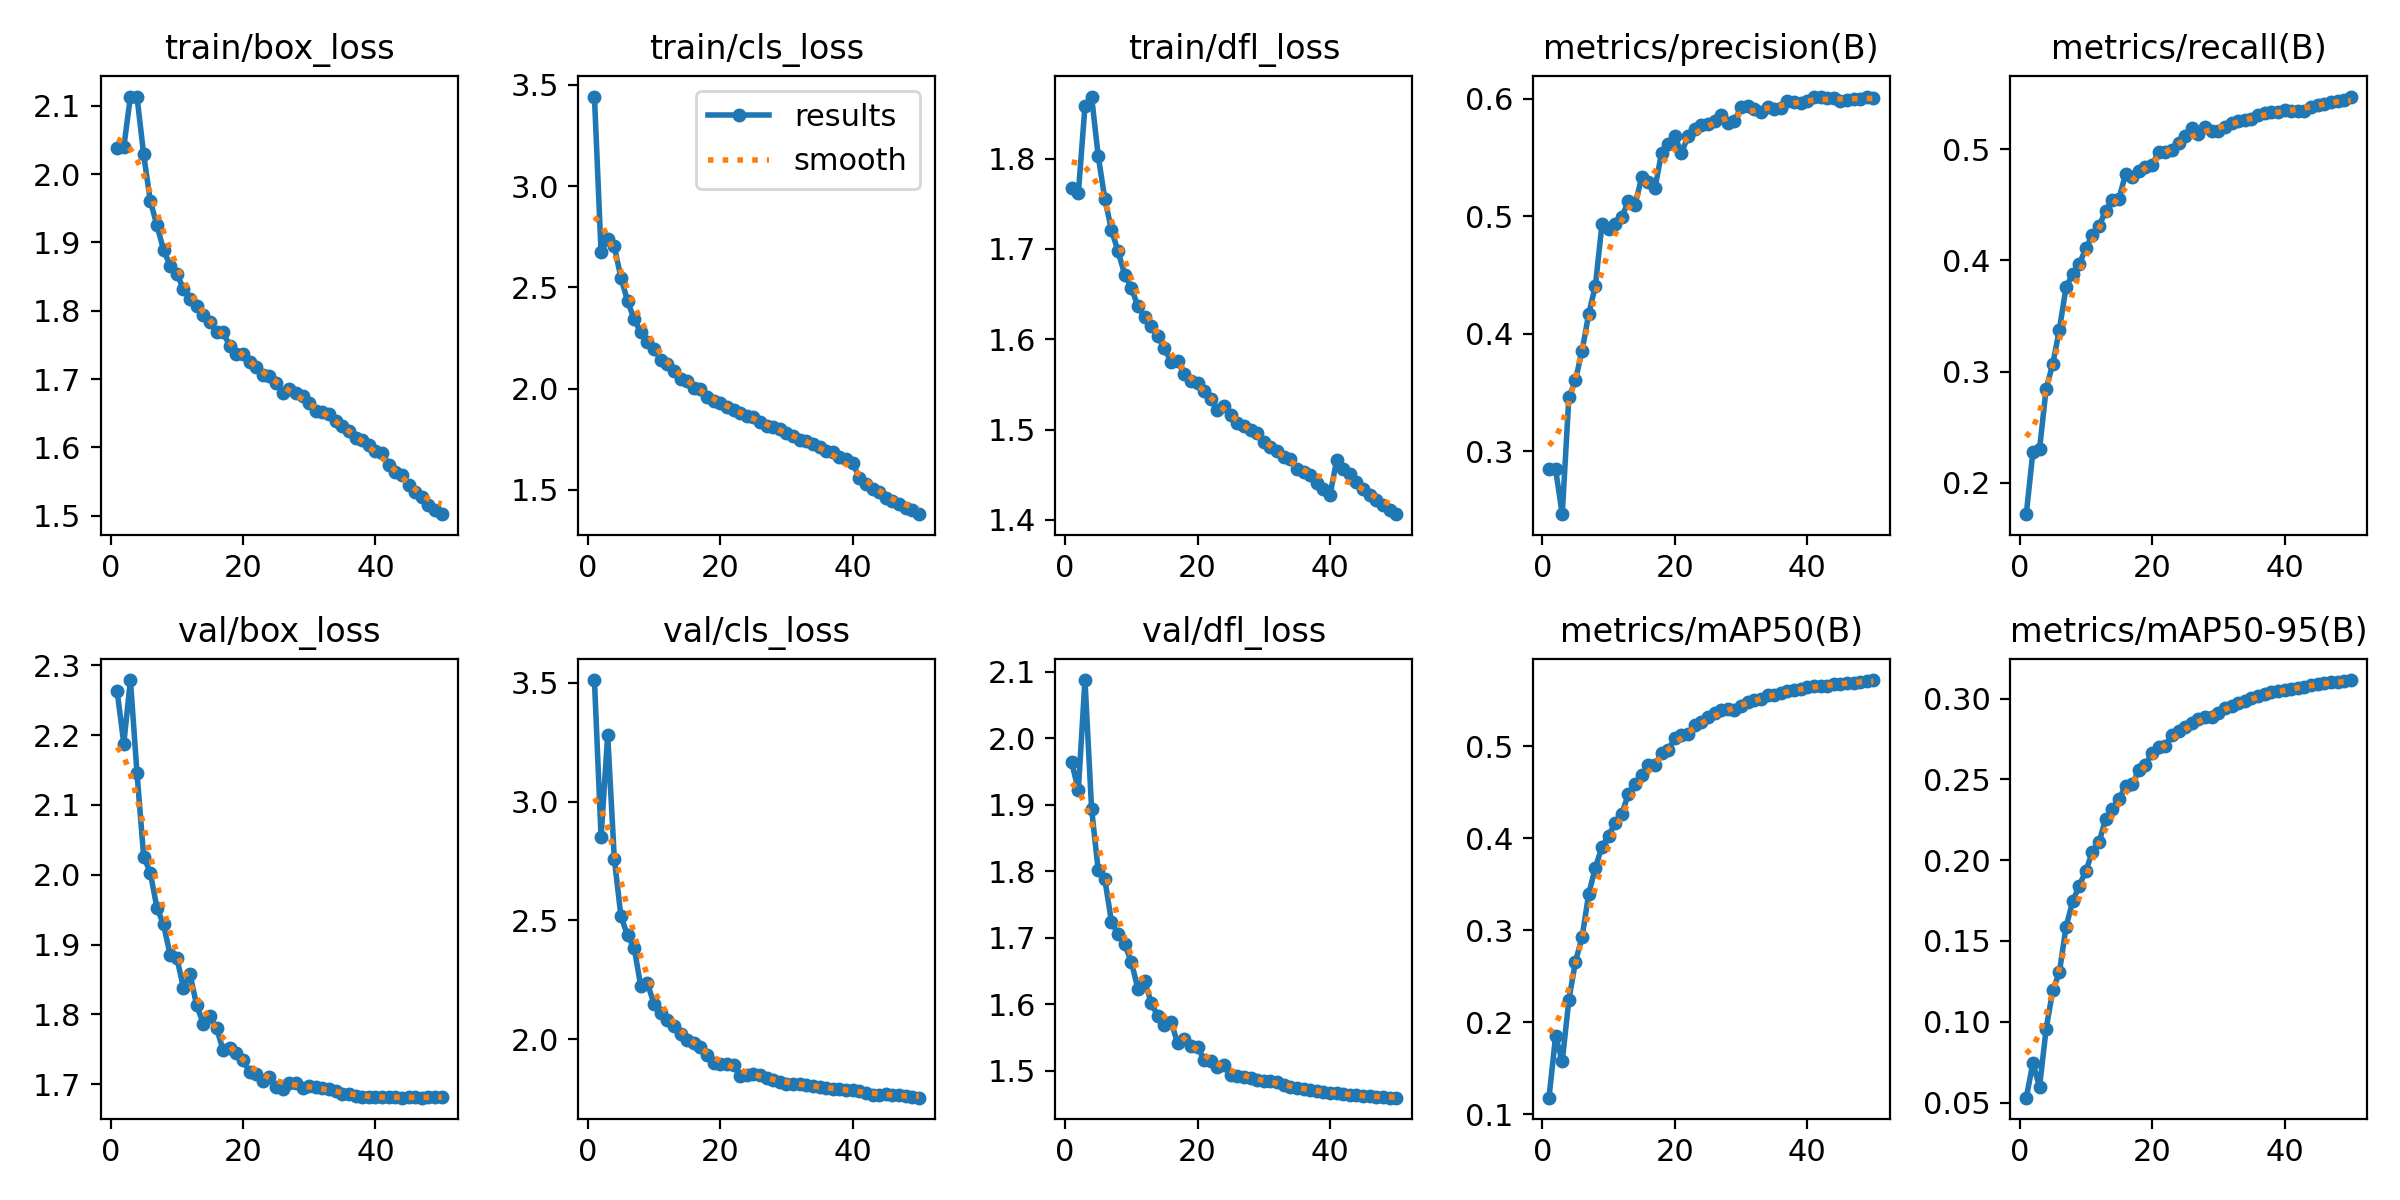

 confusion_matrix.png:


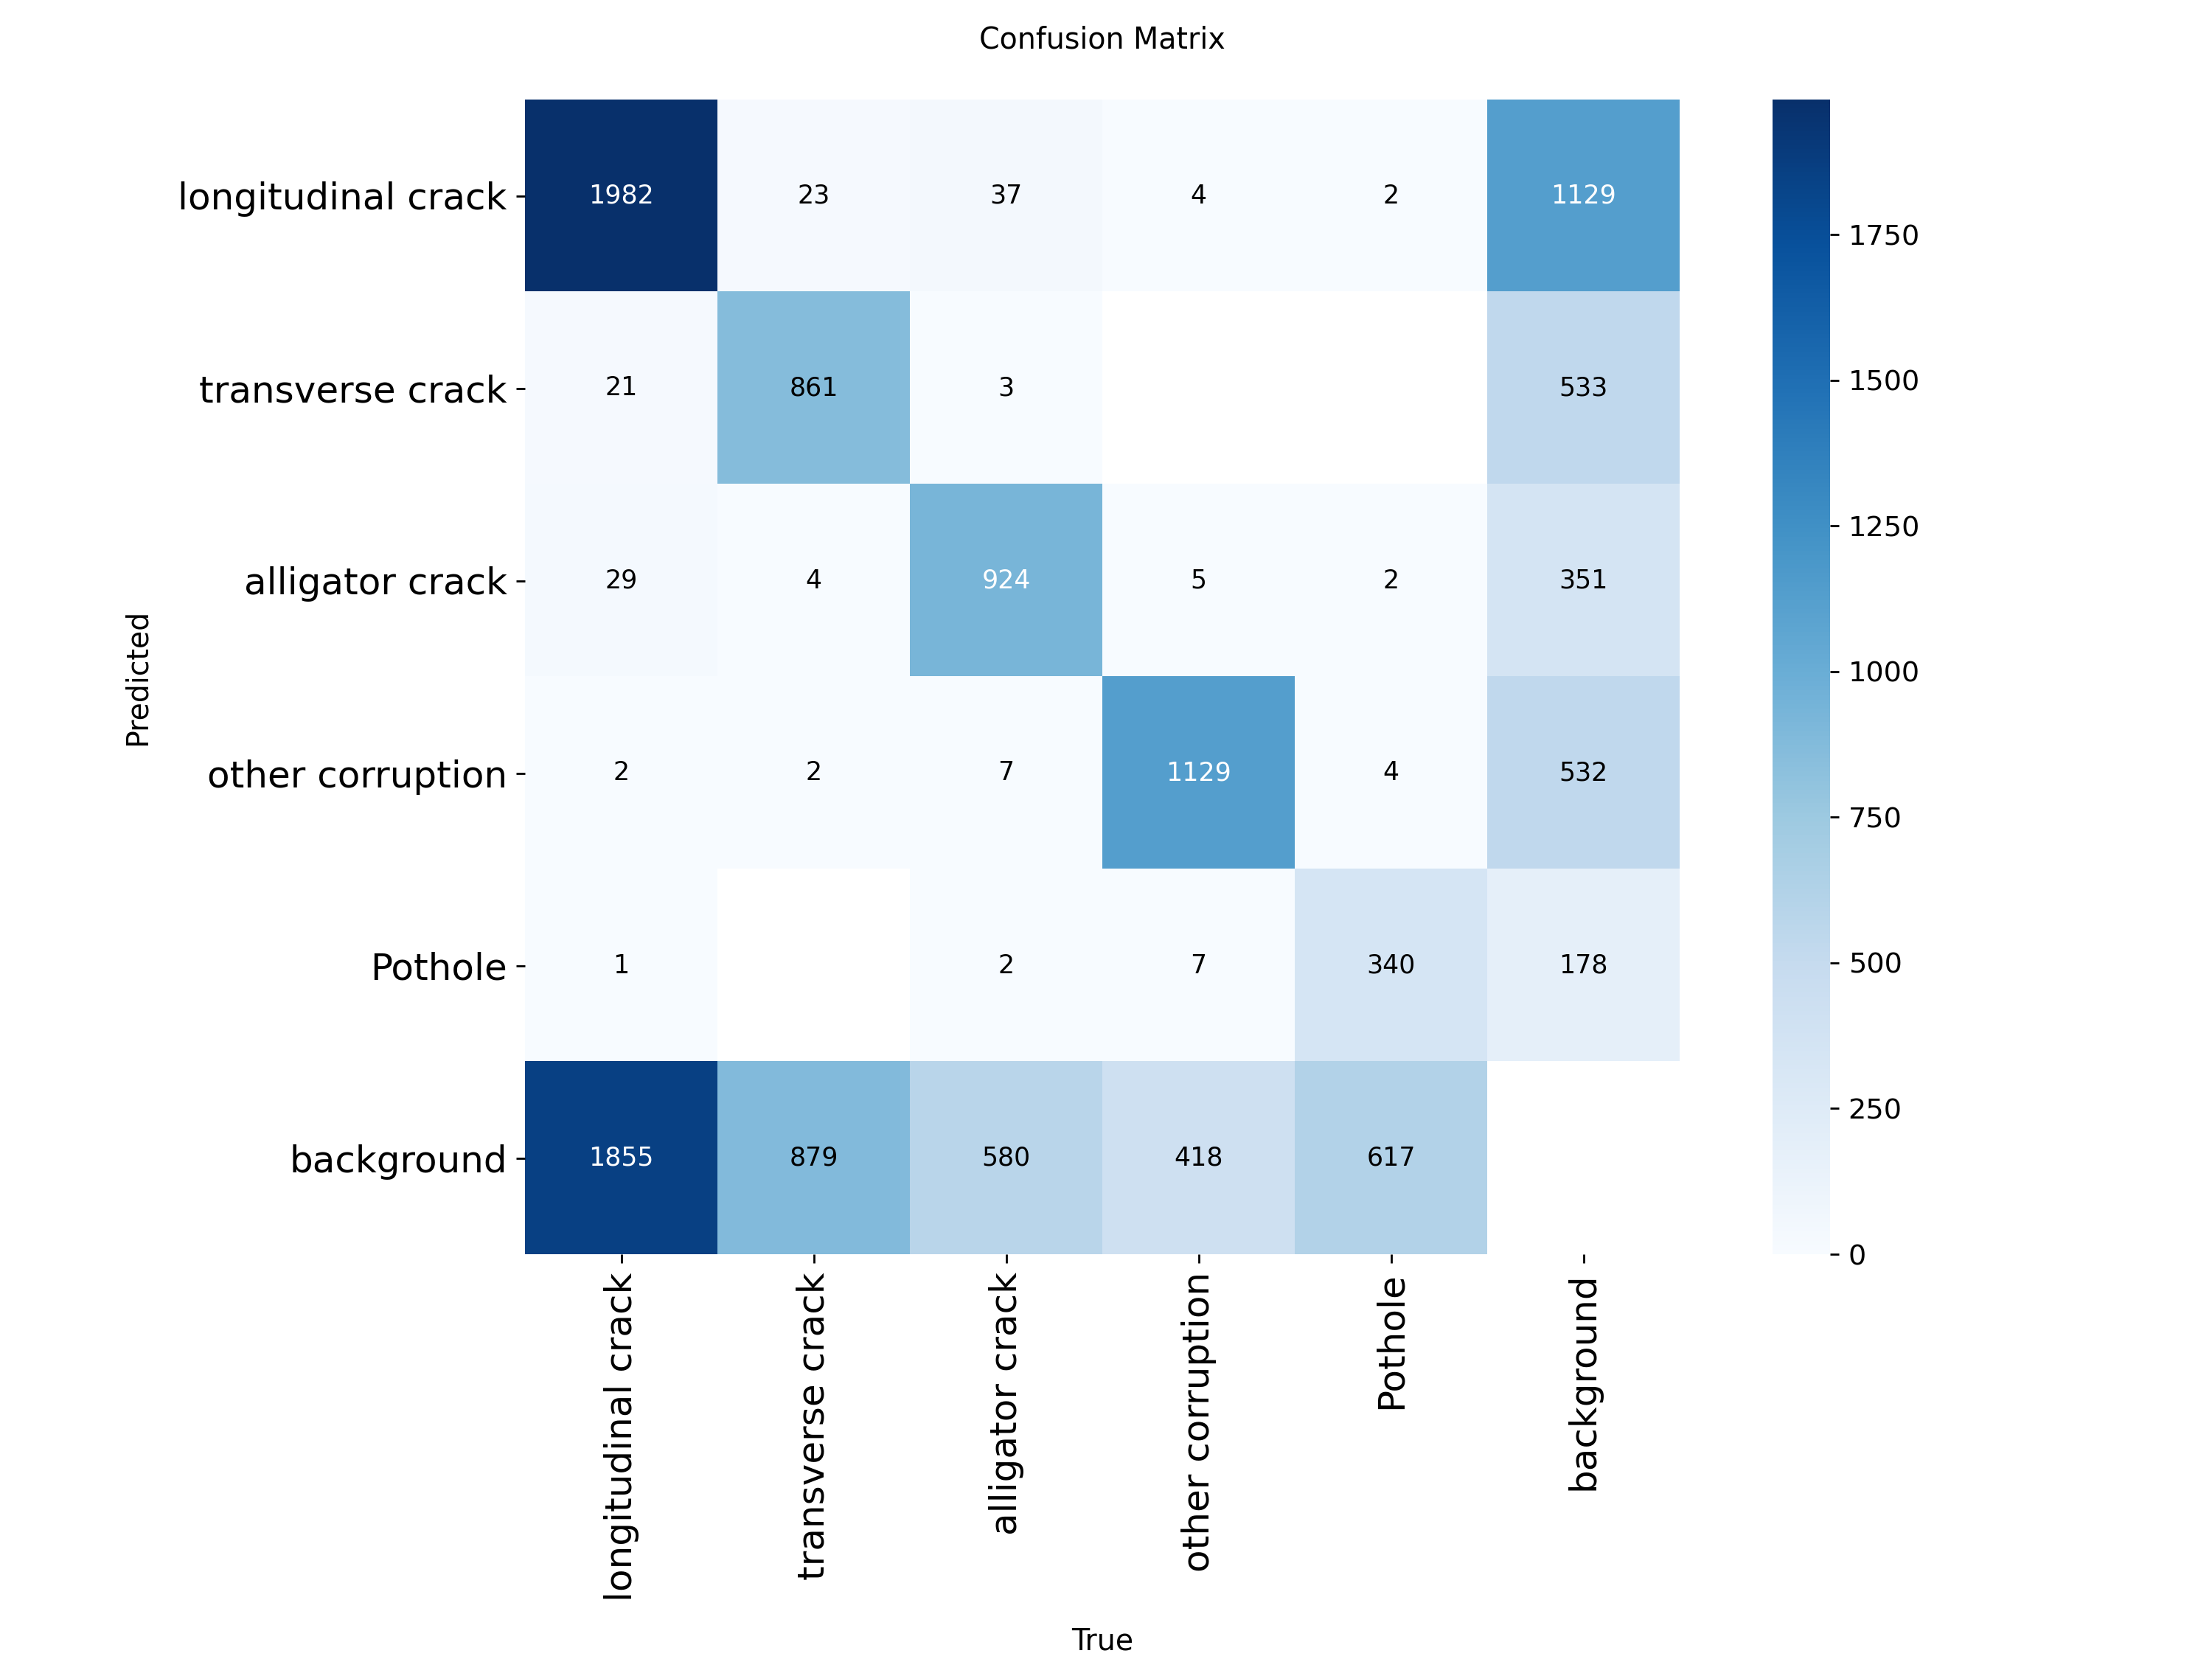

In [10]:
trained_model = YOLO(BEST_MODEL)

print(" Evaluating on test set...")
metrics = trained_model.val(data=YAML_PATH, split="test", verbose=True)

print("\n" + "="*50)
print(" FINAL METRICS")
print("="*50)
print(f"  mAP@50:     {metrics.box.map50:.4f}")
print(f"  mAP@50-95:  {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")

# Per-class AP
print("Per-Class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    try:
        ap = metrics.box.ap50[i]
        print(f"  {name:<22}: {ap:.4f}")
    except:
        pass

plot_dir = Path(PROJECT_DIR) / RUN_NAME
for plot_name in ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    p = plot_dir / plot_name
    if p.exists():
        print(f" {plot_name}:")
        display(Image(str(p), width=800))